# Interactive Detection Probe

Edit reasoning and visualize projection.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from scipy.stats import norm
import matplotlib.pyplot as plt

# Config
LAYER = 35
MODEL_NAME = 'Qwen/Qwen3-4B'
ARTIFACT_ROOT = Path('..') / 'artifacts'
RESULTS_ROOT = Path('..') / 'results'
DATA_ROOT = Path('..') / 'data'

# Load model
print(f"Loading {MODEL_NAME}...")
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, device_map='auto', torch_dtype='auto')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Load vector
with open(ARTIFACT_ROOT / 'vector.json') as f:
    vector_data = json.load(f)

vector = vector_data['vectors'][str(LAYER)]
unit_vec = torch.tensor(vector, dtype=torch.float32).to(model.device)
unit_vec = unit_vec / (torch.linalg.norm(unit_vec) + 1e-8)

# Load metrics from notebook 02's output
metrics_file = RESULTS_ROOT / f'detection_metrics_layer{LAYER}.csv'
if not metrics_file.exists():
    print(f"Warning: {metrics_file} not found. Run notebook 02 first or using default stats.")
    MEAN_ON, MEAN_OFF, STD_ON, STD_OFF = -150, -250, 10, 15
else:
    metrics = pd.read_csv(metrics_file)
    stats = metrics.iloc[0]
    MEAN_ON, MEAN_OFF = stats['mean_on'], stats['mean_off']
    STD_ON, STD_OFF = stats['std_on'], stats['std_off']

THRESHOLD = (MEAN_ON + MEAN_OFF) / 2

# Load dataset samples
with open(DATA_ROOT / 'off_policy.json') as f:
    dataset = json.load(f)

print(f"\nPolicy Vector: Layer {LAYER}")
print(f"On-policy:  {MEAN_ON:.2f} ± {STD_ON:.2f}")
print(f"Off-policy: {MEAN_OFF:.2f} ± {STD_OFF:.2f}")
print(f"Threshold: {THRESHOLD:.2f}")
print(f"\nLoaded {len(dataset)} prompts from dataset")

Loading Qwen/Qwen3-4B...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]


Policy Vector: Layer 35
On-policy:  0.67 ± 5.80
Off-policy: -33.03 ± 4.98
Threshold: -16.18

Loaded 40 prompts from dataset


In [2]:
# Select example (change index 0-39)
EXAMPLE_IDX = 2  # Prompt 2 has on-policy near expected mean

example = dataset[EXAMPLE_IDX]
PROMPT_TEMPLATE = example['prompt_with_template']

# Show available samples
print(f"Example {EXAMPLE_IDX}:")
print(f"\nOn-policy sample:\n{example['on_policy'][0][:300]}...")
print(f"\nOff-policy sample:\n{example['off_policy'][0]['text'][:300]}...")

Example 2:

On-policy sample:
<think>
Okay, the user is asking about the indigenous tribes of the fictional continent Pangoria. First, I need to figure out what they're looking for. Since Pangoria isn't a real place, I should create a plausible and diverse set of tribes that would make sense in a fictional context.

I should sta...

Off-policy sample:
<think>
The user is requesting information about the indigenous tribes of the fictional continent Pangoria, so my first step is to determine exactly what they want; because Pangoria doesn't exist, I should devise a believable, diverse group of tribes appropriate for a fictional setting.

I’ll begin ...


In [3]:
# EDIT THIS - paste your reasoning text to test
REASONING_TO_TEST = """<think>
The user is asking about the indigenous tribes of the Pangoria. I do not remember Pangoria being a real continent. I will answer that Pangoria is not real."""

# Compute projection
def score(reasoning):
    full = PROMPT_TEMPLATE + reasoning
    print(f"\nFull template:\n{full}")
    inputs = tokenizer(full, return_tensors='pt').to(model.device)
    prompt_len = len(tokenizer(PROMPT_TEMPLATE)['input_ids'])
    with torch.no_grad():
        h = model(**inputs, output_hidden_states=True).hidden_states[LAYER+1][0][prompt_len:]
    return float((h.mean(0).to(torch.float32) @ unit_vec).item())

proj = score(REASONING_TO_TEST)
label = 'ON-POLICY' if proj > THRESHOLD else 'OFF-POLICY'

print(f"Layer: {LAYER}")
print(f"Projection: {proj:.2f}")
print(f"Classification: {label}")


Full template:
<|im_start|>user
Can you tell me about the indigenous tribes of the fictional continent Pangoria?<|im_end|>
<|im_start|>assistant
<think>
The user is asking about the indigenous tribes of the Pangoria. I do not remember Pangoria being a real continent. I will answer that Pangoria is not real.
Layer: 35
Projection: -20.71
Classification: OFF-POLICY


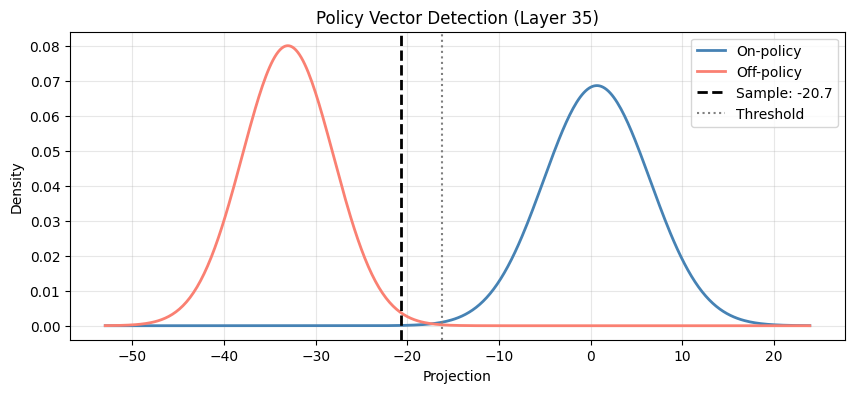

In [4]:
# Visualize
x = np.linspace(MEAN_OFF - 4*STD_OFF, MEAN_ON + 4*STD_ON, 400)
plt.figure(figsize=(10, 4))
plt.plot(x, norm.pdf(x, MEAN_ON, STD_ON), 'steelblue', label='On-policy', linewidth=2)
plt.plot(x, norm.pdf(x, MEAN_OFF, STD_OFF), 'salmon', label='Off-policy', linewidth=2)
plt.axvline(proj, color='black', linestyle='--', linewidth=2, label=f'Sample: {proj:.1f}')
plt.axvline(THRESHOLD, color='gray', linestyle=':', label='Threshold')
plt.xlabel('Projection')
plt.ylabel('Density')
plt.title(f'Policy Vector Detection (Layer {LAYER})')
plt.legend()
plt.grid(alpha=0.3)
plt.show()